SRG Similarity Score: 0.385026
SRG k-NN Score: 0.610418
SRG Proto Score: 0.593364


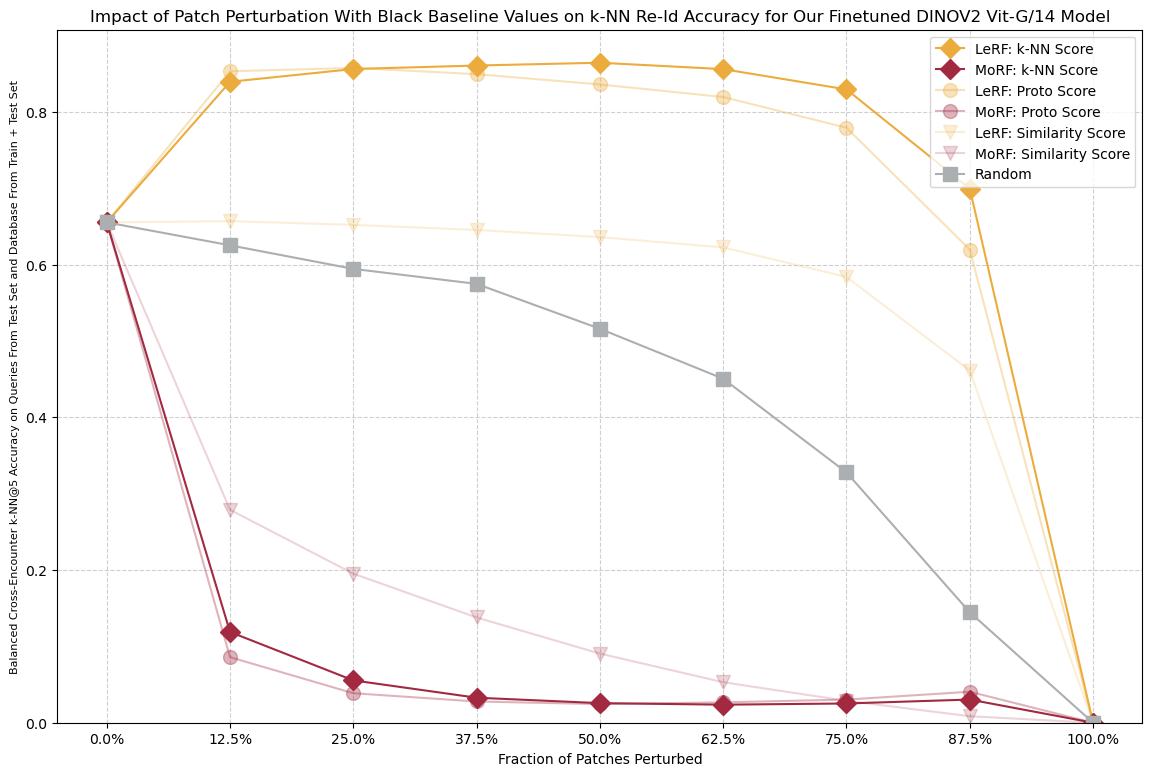

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

hpi_red = (0.6352941176470588, 0.1607843137254902, 0.25098039215686274)
hpi_orange = (0.807843137254902, 0.40784313725490196, 0.17647058823529413)
hpi_yellow = (0.9254901960784314, 0.6745098039215687, 0.23921568627450981)
hpi_gray = (0.6745098039215687, 0.6862745098039216, 0.6980392156862745)

colors = {
    'MoRF': hpi_red,
    'LeRF': hpi_yellow,
    'random': hpi_gray,
}

transparencies_finetuned = {
    'Similarity Score': 0.2,
    'k-NN Score': 1,
    'Proto Score': 0.35
}

markers = {
    'Similarity Score': 'v',    # Dreieck nach unten
    'k-NN Score': 'D',    # Diamond
    'Proto Score': 'o'   # Kreis
}
random_marker = 's'

plot_fractions = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

scores_finetuned = ['k-NN Score', 'Proto Score', 'Similarity Score']
finetuned_results = defaultdict(lambda: defaultdict(list))

finetuned_results['Similarity Score']['MoRF'] = [0.6553029 , 0.2788941 , 0.19523272, 0.13783732, 0.09053982, 0.05305599, 0.02871896, 0.00849313, 0.0]
finetuned_results['Similarity Score']['LeRF'] = [0.6553029 , 0.65691155, 0.6520537 , 0.645382  , 0.63601935, 0.62256277, 0.5838184 , 0.46126226, 0.0]
finetuned_results['Similarity Score']['random'] = [0.6553029 , 0.6252663 , 0.5944094 , 0.5747365 , 0.51597685,0.45054367, 0.32781374, 0.1446348 , 0.0]
srg_finetuned_similarity_score = 0.3850264400243759


finetuned_results['k-NN Score']['MoRF'] = [0.6553029 , 0.11885869, 0.05544575, 0.03276334, 0.02565005, 0.02362726, 0.02521381, 0.03034386, 0.0]
finetuned_results['k-NN Score']['LeRF'] = [0.6553029 , 0.839429  , 0.85617566, 0.86074215, 0.8644064 , 0.85600346, 0.829441  , 0.6994693 , 0.0]
finetuned_results['k-NN Score']['random'] = [0.6553029 , 0.6252663 , 0.5944094 , 0.5747365 , 0.51597685,0.45054367, 0.32781374, 0.1446348 , 0.0]
srg_finetuned_knn_score = 0.6104182600975037

finetuned_results['Proto Score']['MoRF'] = [0.6553029 , 0.08587865, 0.03862392, 0.02780344, 0.02440522, 0.0266853 , 0.03029442, 0.04056211, 0.0]
finetuned_results['Proto Score']['LeRF'] = [0.6553029 , 0.853193  , 0.8575938 , 0.8494396 , 0.8359437 , 0.81947523, 0.7792357 , 0.6196446 , 0.0]
finetuned_results['Proto Score']['random'] = [0.6553029 , 0.6252663 , 0.5944094 , 0.5747365 , 0.51597685, 0.45054367, 0.32781374, 0.1446348 , 0.0]
srg_finetuned_proto_score = 0.5933635905385017


#Symmetric Relevane Gain as per Blücher et al. http://arxiv.org/abs/2401.06654 or what I call "faithfuleness" in my thesis
print(f"SRG Similarity Score: {srg_finetuned_similarity_score:.6f}")
print(f"SRG k-NN Score: {srg_finetuned_knn_score:.6f}")
print(f"SRG Proto Score: {srg_finetuned_proto_score:.6f}")

plt.figure(figsize=(14, 9))


for score in scores_finetuned:
    for mode in ['LeRF', 'MoRF']:
        plt.plot(plot_fractions, 
                    finetuned_results[score][mode], 
                    marker=markers[score],
                    markersize=10,
                    linestyle='-', 
                    alpha=transparencies_finetuned[score],
                    label=mode + ': ' + score, 
                    color=colors.get(mode, 'black')
                )

plt.plot(plot_fractions,
         finetuned_results['k-NN Score']['random'],
         marker=random_marker,
         markersize=10,
         linestyle='-',
         color=colors['random'],
         label='Random')

plt.title(f'Impact of Patch Perturbation With Black Baseline Values on k-NN Re-Id Accuracy for Our Finetuned DINOV2 Vit-G/14 Model')
plt.xlabel('Fraction of Patches Perturbed')
plt.ylabel(f"Balanced Cross-Encounter k-NN@5 Accuracy on Queries From Test Set and Database From Train + Test Set of \n spac23+24-body_face-squared-deduplicated", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0)
plt.xticks(plot_fractions, [f'{p*100:.1f}%' for p in plot_fractions])
plt.show()

SRG Similarity Score: 0.167842
SRG k-NN Score: 0.323337
SRG Proto Score: 0.352211


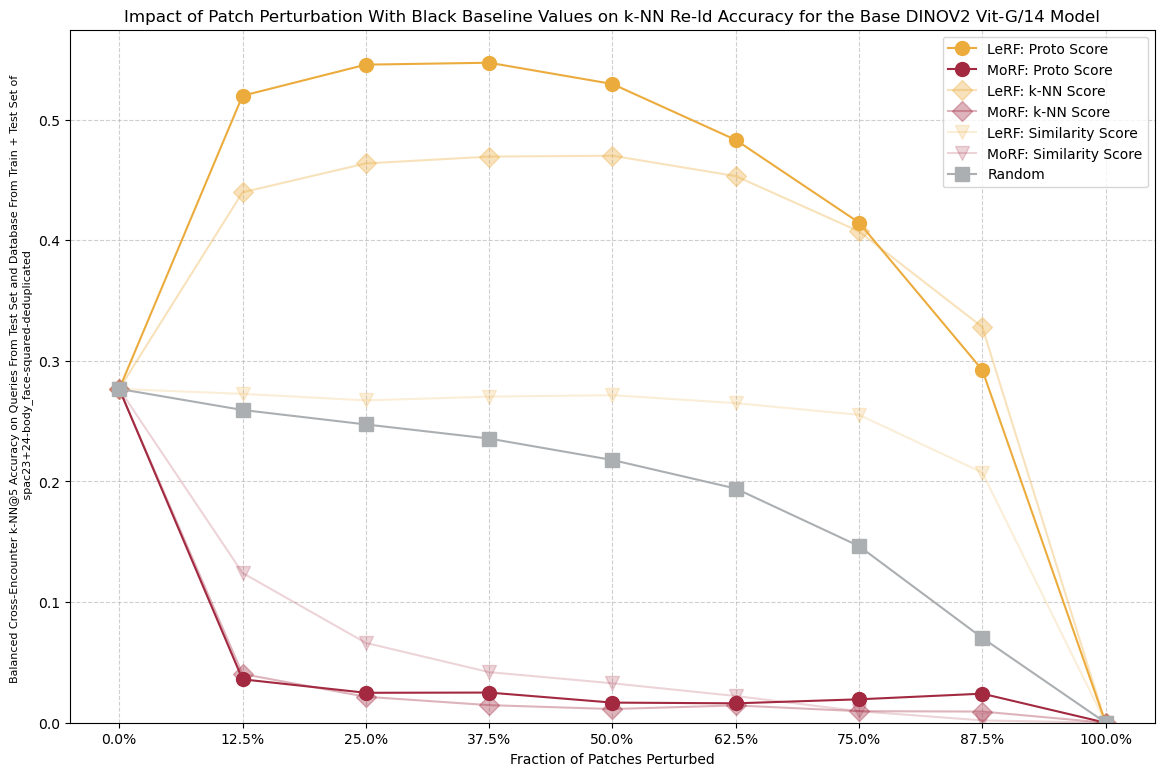

In [6]:
scores_base  = ['Proto Score', 'k-NN Score', 'Similarity Score']
transparencies_base = {
    'Similarity Score': 0.2,
    'k-NN Score': 0.35,
    'Proto Score': 1
}

base_results = defaultdict(lambda: defaultdict(list))
base_results['Similarity Score']['MoRF'] = [0.2766598 , 0.12416789, 0.06617787, 0.04192629, 0.03269458, 0.02214742, 0.0095286 , 0.00192754, 0.0]
base_results['Similarity Score']['LeRF'] = [0.2766598 , 0.27260914, 0.26720014, 0.27030215, 0.27151152, 0.26492536, 0.25523216, 0.2073656 , 0.0]
base_results['Similarity Score']['random'] = [0.2766598 , 0.25925806, 0.24726664, 0.23556039, 0.21778983, 0.19412133, 0.14642756, 0.0703163 , 0.0]
srg_base_similarity_score = 0.16784176975488663

base_results['k-NN Score']['MoRF'] = [0.2766598 , 0.04040144, 0.02152744, 0.01457032, 0.01134089, 0.01435378, 0.0095634 , 0.00925959, 0.0]
base_results['k-NN Score']['LeRF'] = [0.2766598 , 0.4396879 , 0.46361935, 0.46928522, 0.470007  , 0.45313865, 0.40728545, 0.32802194, 0.0]
base_results['k-NN Score']['random'] = [0.2766598 , 0.25925806, 0.24726664, 0.23556039, 0.21778983, 0.19412133, 0.14642756, 0.0703163 , 0.0]
srg_base_knn_score = 0.32333654165267944

base_results['Proto Score']['MoRF'] = [0.2766598 , 0.03598756, 0.0248167 , 0.02499161, 0.01667794, 0.01607466, 0.01940517, 0.02408382, 0.0]
base_results['Proto Score']['LeRF'] = [0.2766598 , 0.5197222 , 0.54550683, 0.5471069 , 0.52948207,0.4831182 , 0.41457537, 0.29242468, 0.0]
base_results['Proto Score']['random'] = [0.2766598 , 0.25925806, 0.24726664, 0.23556039, 0.21778983, 0.19412133, 0.14642756, 0.0703163 , 0.0]
srg_base_proto_score = 0.35221097245812416

#Symmetric Relevane Gain as per Blücher et al. http://arxiv.org/abs/2401.06654 or what I call "faithfuleness" in my thesis
print(f"SRG Similarity Score: {srg_base_similarity_score:.6f}")
print(f"SRG k-NN Score: {srg_base_knn_score:.6f}")
print(f"SRG Proto Score: {srg_base_proto_score:.6f}")

plt.figure(figsize=(14, 9))


for score in scores_base:
    for mode in ['LeRF', 'MoRF']:
        plt.plot(plot_fractions, 
                    base_results[score][mode], 
                    marker=markers[score],
                    markersize=10,
                    linestyle='-', 
                    alpha=transparencies_base[score],
                    label=mode + ': ' + score, 
                    color=colors.get(mode, 'black')
                )

plt.plot(plot_fractions,
         base_results['k-NN Score']['random'],
         marker=random_marker,
         markersize=10,
         linestyle='-',
         color=colors['random'],
         label='Random')

plt.title(f'Impact of Patch Perturbation With Black Baseline Values on k-NN Re-Id Accuracy for the Base DINOV2 Vit-G/14 Model')
plt.xlabel('Fraction of Patches Perturbed')
plt.ylabel(f"Balanced Cross-Encounter k-NN@5 Accuracy on Queries From Test Set and Database From Train + Test Set of \n spac23+24-body_face-squared-deduplicated", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0)
plt.xticks(plot_fractions, [f'{p*100:.1f}%' for p in plot_fractions])
plt.show()